In [ ]:
# This program is for the book "Digital Image Processing" by Dr. Mahmood Azimi-Sadjadi.
# Copyright Copyright (c) 2026 Yifan Yang and Dr. Mahmood Azimi-Sadjadi.
# Contact: mahmood.azimi-sadjadi@colostate.edu

# Connect Colab to Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Perform PCA on GOES Data

(6, 1500, 3000)
0
1
2
3
4
5


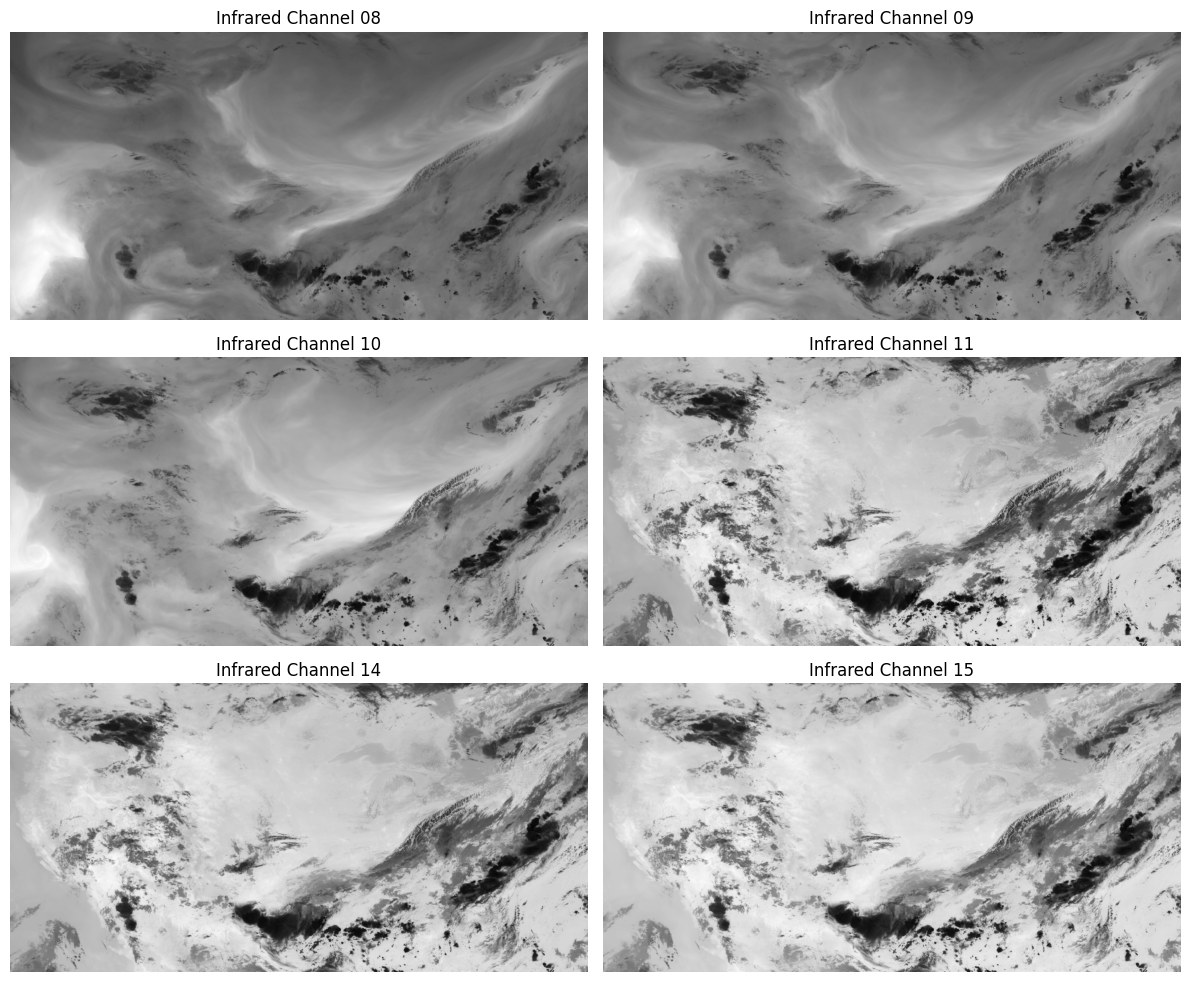

In [ ]:
import numpy as np
from matplotlib import pyplot as plt
import gc
import os

work_path = "/content/drive/MyDrive/DigitalImageProcessing/"

# load GOES Data
goes_data = []
select_channels = ['C08', 'C09', 'C10', 'C11', 'C14', 'C15']

for sc in select_channels:
    goes_data.append(np.load(work_path + 'Data/GOES_Data/GOES_' + sc + '.npy'))

goes_data = np.array(goes_data)
print(goes_data.shape)

# display original GOES data
fig, ax = plt.subplots(3, 2, figsize=(12,10))
for i in range(3):
    for j in range(2):
        print(i*2+j)
        im = ax[i,j].imshow(goes_data[i*2+j], cmap='gray')
        ax[i,j].axis('off')
        ax[i,j].set_title("Infrared Channel " + str(select_channels[i*2+j][1:]))

fig.tight_layout()
plt.show()

In [ ]:
# perform PCA
from sklearn.decomposition import PCA

goes_data = np.reshape(goes_data, (goes_data.shape[0], -1))

pca = PCA(n_components=4).fit(goes_data.T)

PCs = np.matmul(pca.components_, goes_data)

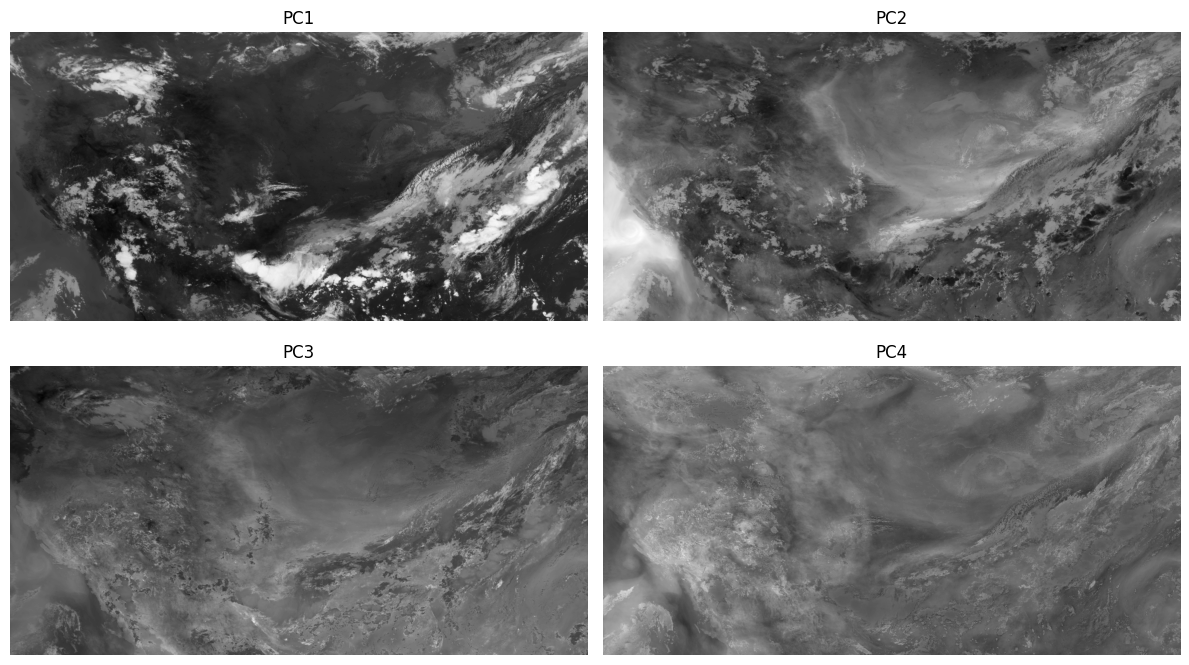

[1.00333499e+03 5.44685454e+00 1.94026376e+00 2.83066702e-01]


In [ ]:
# Display PCs
fig, ax = plt.subplots(2, 2, figsize=(12, 7))
title_list = ['PC1', 'PC2', 'PC3', 'PC4']
for i in range(2):
  for j in range(2):
        ax[i,j].imshow(np.reshape(PCs[i*2+j],(1500, 3000)), cmap='gray')
        ax[i,j].axis('off')
        ax[i,j].set_title(title_list[i*2+j])
fig.tight_layout()
plt.show()
print(pca.explained_variance_)